# 02 - Modelado con red neuronal y aprendizaje por refuerzo contextual

En este notebook construimos modelos deliberadamente poco transparentes para justificar después una auditoría XAI sólida.

Se entrenan dos enfoques:

1. **Red neuronal supervisada MLP** para estimar la probabilidad de morosidad grave.
2. **Política de aprendizaje por refuerzo contextual / contextual bandit**, donde cada cliente es un contexto y el modelo decide si clasificarlo como bajo o alto riesgo.

La práctica exige dos escenarios de coste:

- Escenario 1: coste falso positivo = 1, coste falso negativo = 1.
- Escenario 2: coste falso positivo = 1, coste falso negativo = 10.

Interpretación de errores:

- Falso positivo: el modelo predice `1` —cliente malo / denegar— pero realmente era `0`. Coste: se rechaza a un cliente bueno.
- Falso negativo: el modelo predice `0` —cliente bueno / conceder— pero realmente era `1`. Coste: se concede crédito a un cliente con mora grave. En el segundo escenario este error cuesta diez veces más.

In [15]:
# ==============================
# Imports
# ==============================

from __future__ import annotations

import json
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import joblib

# Necesario para poder reconstruir ScaledKNNImputer al cargar
# preprocessing_objects.joblib (ver preprocessing_utils.py).
from preprocessing_utils import ScaledKNNImputer  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Para reproducibilidad. En GPU puede hacer el entrenamiento más lento, pero aquí se prioriza estabilidad.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

OUTPUT_DIR = Path("outputs")
OBJECTS_DIR = OUTPUT_DIR / "objects"
MODELS_DIR = OUTPUT_DIR / "models"
PLOTS_DIR = OUTPUT_DIR / "plots"

for p in [OUTPUT_DIR, OBJECTS_DIR, MODELS_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

Device: cpu


## 1. Carga de datos preprocesados

Este notebook asume que se ha ejecutado antes `01_EDA_Preprocesado.ipynb`. Si no existen los ficheros preprocesados, se lanza un error claro para evitar entrenar con datos sin limpiar.

In [16]:
train_preprocessed_path = OUTPUT_DIR / "preprocessed_train.csv"
preprocessing_objects_path = OBJECTS_DIR / "preprocessing_objects.joblib"

if not train_preprocessed_path.exists() or not preprocessing_objects_path.exists():
    raise FileNotFoundError(
        "No se encuentran los datos preprocesados. Ejecuta primero 01_EDA_Preprocesado.ipynb."
    )

train_df = pd.read_csv(train_preprocessed_path)
preprocessing_objects = joblib.load(preprocessing_objects_path)

TARGET = preprocessing_objects["target"]
FEATURES = preprocessing_objects["final_features"]

print("Train preprocesado:", train_df.shape)
print("Target:", TARGET)
print("N features:", len(FEATURES))

Train preprocesado: (104669, 26)
Target: SeriousDlqin2yrs
N features: 16


In [17]:
# Separamos X e y. La comparación de modelos y la búsqueda de threshold
# se hacen ahora con validación cruzada (ver sección 2.5), no con un único
# split 80/20: un solo split puede dar un threshold "de suerte" que no
# se sostenga en otra partición de los datos.
X = train_df[FEATURES].astype(float).copy()
y = train_df[TARGET].astype(int).copy()

print("Distribución target:")
print(y.value_counts(normalize=True).rename("pct"))
print("\nX:", X.shape)


Distribución target:
SeriousDlqin2yrs
0   0.9330
1   0.0670
Name: pct, dtype: float64

X: (104669, 16)


## 2. Función de coste y métricas

La métrica clave para entregar predicciones es el coste esperado bajo cada escenario.

Usaremos también métricas estándar para entender el comportamiento:

- ROC AUC: capacidad de ranking global.
- PR AUC: útil cuando la clase positiva es minoritaria.
- Recall clase 1: proporción de morosos graves detectados.
- Precision clase 1: de los marcados como morosos, cuántos lo eran.
- F1: equilibrio precision/recall.
- MCC: métrica robusta para clasificación desbalanceada.
- Balanced accuracy: media del recall de ambas clases.

In [18]:
def cost_from_predictions(y_true: np.ndarray, y_pred: np.ndarray, fp_cost: float, fn_cost: float) -> Dict[str, float]:
    """
    Calcula coste total y promedio a partir de y real y predicción binaria.

    Convención:
    - y_pred = 1 significa predecir morosidad grave / denegar crédito.
    - y_pred = 0 significa predecir no morosidad / conceder crédito.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    total_cost = fp_cost * fp + fn_cost * fn
    avg_cost = total_cost / len(y_true)
    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "total_cost": total_cost,
        "avg_cost": avg_cost,
    }


def find_best_threshold(y_true: np.ndarray, y_proba: np.ndarray, fp_cost: float, fn_cost: float) -> Tuple[float, pd.DataFrame]:
    """
    Busca el threshold que minimiza el coste en validación.

    No se fija 0.5 porque en problemas de riesgo el threshold óptimo depende del coste relativo.
    """
    thresholds = np.linspace(0.01, 0.99, 199)
    rows = []

    for thr in thresholds:
        pred = (y_proba >= thr).astype(int)
        cost = cost_from_predictions(y_true, pred, fp_cost=fp_cost, fn_cost=fn_cost)
        rows.append({"threshold": thr, **cost})

    table = pd.DataFrame(rows)
    best_row = table.sort_values(["avg_cost", "threshold"]).iloc[0]
    return float(best_row["threshold"]), table


def evaluate_binary_model(
    name: str,
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float,
    fp_cost: float,
    fn_cost: float,
) -> Dict[str, float]:
    """Evalúa un modelo probabilístico usando un threshold concreto."""
    y_pred = (y_proba >= threshold).astype(int)
    cost = cost_from_predictions(y_true, y_pred, fp_cost=fp_cost, fn_cost=fn_cost)

    metrics = {
        "model": name,
        "threshold": threshold,
        "fp_cost": fp_cost,
        "fn_cost": fn_cost,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_1": precision_score(y_true, y_pred, zero_division=0),
        "recall_1": recall_score(y_true, y_pred, zero_division=0),
        "f1_1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        **cost,
    }
    return metrics


def print_confusion_and_report(y_true: np.ndarray, y_pred: np.ndarray):
    """Imprime matriz de confusión y classification report."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    display(pd.DataFrame(cm, index=["real_0", "real_1"], columns=["pred_0", "pred_1"]))
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

## 3. Modelo 1: Red neuronal supervisada MLP

La MLP toma todas las variables tabulares preprocesadas y produce un logit. Tras aplicar sigmoide, obtenemos una probabilidad estimada de `SeriousDlqin2yrs = 1`.

Arquitectura:

- Capa densa 1.
- BatchNorm para estabilizar entrenamiento.
- ReLU.
- Dropout para reducir sobreajuste.
- Capa densa 2.
- BatchNorm + ReLU + Dropout.
- Capa densa 3.
- Salida binaria.

Para tratar el desbalanceo usamos `pos_weight` en `BCEWithLogitsLoss`, penalizando más los errores sobre la clase minoritaria durante el entrenamiento.

In [19]:
class CreditMLP(nn.Module):
    """
    Red neuronal feed-forward para clasificación binaria.

    Devuelve logits, no probabilidades. Para obtener probabilidades se aplica sigmoid.
    """
    def __init__(self, input_dim: int, hidden_dims: Tuple[int, int, int] = (128, 64, 32), dropout: float = 0.25):
        super().__init__()
        h1, h2, h3 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(h3, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def make_dataloaders(X_tr, y_tr, X_va, y_va, batch_size: int = 1024):
    """Crea dataloaders de PyTorch desde arrays numpy."""
    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr.values if hasattr(y_tr, "values") else y_tr, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va.values if hasattr(y_va, "values") else y_va, dtype=torch.float32),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def predict_mlp_proba(model: nn.Module, X_array: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    """Predice probabilidades con la MLP en batches."""
    model.eval()
    probs = []
    with torch.no_grad():
        for start in range(0, len(X_array), batch_size):
            xb = torch.tensor(X_array[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            prob = torch.sigmoid(logits).cpu().numpy()
            probs.append(prob)
    return np.concatenate(probs)


def train_mlp(
    X_tr: np.ndarray,
    y_tr: pd.Series,
    X_va: np.ndarray,
    y_va: pd.Series,
    input_dim: int,
    hidden_dims: Tuple[int, int, int] = (128, 64, 32),
    dropout: float = 0.25,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    use_pos_weight: bool = True,
    batch_size: int = 1024,
    max_epochs: int = 80,
    patience: int = 10,
    lr_scheduler_patience: int | None = None,
    lr_scheduler_factor: float = 0.5,
    min_lr: float = 1e-5,
) -> Tuple[CreditMLP, pd.DataFrame]:
    """
    Entrena la red neuronal con early stopping.

    El criterio de early stopping es la loss de validación.
    """
    train_loader, val_loader = make_dataloaders(X_tr, y_tr, X_va, y_va, batch_size=batch_size)

    model = CreditMLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout).to(DEVICE)

    # pos_weight = negativos / positivos.
    n_pos = float((y_tr == 1).sum())
    n_neg = float((y_tr == 0).sum())
    positive_weight = n_neg / max(n_pos, 1.0) if use_pos_weight else 1.0
    pos_weight = torch.tensor([positive_weight], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = None
    if lr_scheduler_patience is not None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=lr_scheduler_factor,
            patience=lr_scheduler_patience,
            min_lr=min_lr,
        )

    best_val_loss = np.inf
    best_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))

        val_proba = predict_mlp_proba(model, X_va)
        val_auc = roc_auc_score(y_va, val_proba)
        val_pr_auc = average_precision_score(y_va, val_proba)

        # Solo actúa cuando se activa explícitamente en la llamada.
        if scheduler is not None:
            scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_roc_auc": val_auc,
            "val_pr_auc": val_pr_auc,
            "learning_rate": current_lr,
        })

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f} | lr={current_lr:.2e}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping en epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

## 4. Modelo 2: aprendizaje por refuerzo contextual / contextual bandit

Formulamos el problema como una decisión de un solo paso:

- **Contexto**: variables del cliente.
- **Acción 0**: clasificar como no moroso grave / conceder.
- **Acción 1**: clasificar como moroso grave / denegar.
- **Recompensa**: depende de si la decisión coincide con la etiqueta real y del coste de equivocarse.

Como tenemos histórico etiquetado, podemos simular la recompensa de ambas acciones para cada cliente. Entrenamos una política neuronal que maximiza recompensa esperada.

Este enfoque encaja con la idea de *multi-armed bandit contextual*: cada cliente es un contexto y las acciones son brazos. El modelo no se limita a estimar una probabilidad, sino que aprende una política de decisión bajo una función de coste.

In [20]:
class ContextualBanditPolicy(nn.Module):
    """
    Política neuronal para contextual bandit con dos acciones.

    Salida:
    - logits de tamaño 2: acción 0 y acción 1.
    - softmax(logits): probabilidad de elegir cada acción.
    """
    def __init__(self, input_dim: int, hidden_dims: Tuple[int, int] = (128, 64), dropout: float = 0.20):
        super().__init__()
        h1, h2 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.BatchNorm1d(h1),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.BatchNorm1d(h2),
            nn.Dropout(dropout),
            nn.Linear(h2, 2),
        )

    def forward(self, x):
        return self.net(x)


def reward_matrix(y_true: torch.Tensor, fp_cost: float, fn_cost: float, pos_weight: float = 1.0) -> torch.Tensor:
    """
    Matriz de recompensas R para acciones [0, 1].

    Acción 0: predecir 0.
    Acción 1: predecir 1.

    Si la acción acierta: +1.
    Si falla:
    - acción 1 cuando y=0 -> falso positivo -> -fp_cost.
    - acción 0 cuando y=1 -> falso negativo -> -fn_cost.

    pos_weight amplifica la magnitud de la recompensa/penalización en las
    filas donde y=1 (la clase minoritaria). Es el mismo truco que ya usa la
    MLP con `pos_weight` en BCEWithLogitsLoss: con costes 1:1 y solo ~6.7%
    de positivos, la jugada más rentable en promedio es casi "decir siempre
    que no", así que el bandit apenas tiene incentivo para aprender a
    diferenciar bien. Con pos_weight > 1, equivocarse (o acertar) en un
    cliente moroso pesa más en la recompensa esperada, dándole al bandit un
    motivo real para prestar atención a esos casos.
    """
    y_true = y_true.long()
    r0 = torch.where(y_true == 0, torch.tensor(1.0, device=y_true.device), torch.tensor(-float(fn_cost), device=y_true.device))
    r1 = torch.where(y_true == 1, torch.tensor(1.0, device=y_true.device), torch.tensor(-float(fp_cost), device=y_true.device))

    minority_weight = torch.where(
        y_true == 1,
        torch.tensor(float(pos_weight), device=y_true.device),
        torch.tensor(1.0, device=y_true.device),
    )
    r0 = r0 * minority_weight
    r1 = r1 * minority_weight

    return torch.stack([r0, r1], dim=1)


def train_contextual_bandit(
    X_tr: np.ndarray,
    y_tr: pd.Series,
    X_va: np.ndarray,
    y_va: pd.Series,
    fp_cost: float,
    fn_cost: float,
    input_dim: int,
    lr: float = 1e-3,
    batch_size: int = 1024,
    max_epochs: int = 80,
    patience: int = 10,
    use_pos_weight: bool = True,
) -> Tuple[ContextualBanditPolicy, pd.DataFrame]:
    """
    Entrena una política de bandit maximizando recompensa esperada.

    La loss es la recompensa esperada negativa:
        loss = - mean(sum_a pi(a|x) * R(a, y))

    Con use_pos_weight=True, se calcula pos_weight = n_negativos / n_positivos
    del propio fold de entrenamiento (igual que en la MLP) y se usa dentro de
    reward_matrix para compensar el desbalanceo de clases.
    """
    train_loader, val_loader = make_dataloaders(X_tr, y_tr, X_va, y_va, batch_size=batch_size)
    model = ContextualBanditPolicy(input_dim=input_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    if use_pos_weight:
        n_pos = float((y_tr == 1).sum())
        n_neg = float((y_tr == 0).sum())
        pos_weight = n_neg / max(n_pos, 1.0)
    else:
        pos_weight = 1.0

    best_val_reward = -np.inf
    best_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_rewards = []
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            probs = F.softmax(logits, dim=1)
            rewards = reward_matrix(yb, fp_cost=fp_cost, fn_cost=fn_cost, pos_weight=pos_weight)
            expected_reward = (probs * rewards).sum(dim=1).mean()
            loss = -expected_reward
            loss.backward()
            optimizer.step()

            train_rewards.append(expected_reward.item())
            train_losses.append(loss.item())

        model.eval()
        val_rewards = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                probs = F.softmax(logits, dim=1)
                rewards = reward_matrix(yb, fp_cost=fp_cost, fn_cost=fn_cost, pos_weight=pos_weight)
                expected_reward = (probs * rewards).sum(dim=1).mean()
                val_rewards.append(expected_reward.item())

        train_reward = float(np.mean(train_rewards))
        val_reward = float(np.mean(val_rewards))
        train_loss = float(np.mean(train_losses))

        val_action_proba = predict_bandit_action1_proba(model, X_va)
        val_actions = (val_action_proba >= 0.5).astype(int)
        val_cost = cost_from_predictions(y_va.values, val_actions, fp_cost=fp_cost, fn_cost=fn_cost)["avg_cost"]

        history.append({
            "epoch": epoch,
            "train_expected_reward": train_reward,
            "val_expected_reward": val_reward,
            "train_loss": train_loss,
            "val_avg_cost": val_cost,
        })

        if val_reward > best_val_reward + 1e-5:
            best_val_reward = val_reward
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_reward={train_reward:.4f} | val_reward={val_reward:.4f} | val_cost={val_cost:.4f}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping en epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def predict_bandit_action1_proba(model: nn.Module, X_array: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    """Devuelve probabilidad de acción 1 según la política del bandit."""
    model.eval()
    probs_out = []
    with torch.no_grad():
        for start in range(0, len(X_array), batch_size):
            xb = torch.tensor(X_array[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            probs_out.append(probs)
    return np.concatenate(probs_out)


## 4.1 Modelo 3: bandit contextual con feedback parcial (IPS)

El bandit de la sección anterior tiene una limitación de fondo: calcula la
recompensa de **las dos acciones a la vez** para cada cliente, usando su
etiqueta real. Un bandit contextual "de verdad" solo observaría la
recompensa de la acción que **realmente elige** — igual que en un banco
real, donde solo sabes qué pasó con los clientes a los que sí concediste
crédito, no con los que rechazaste.

Como no tenemos datos de una interacción real con feedback parcial (el
dataset es de scoring clásico, con la etiqueta siempre conocida), lo
simulamos:

1. **Política de logging**: un modelo sencillo (regresión logística) que
   representa "lo que un sistema más simple habría decidido en el pasado".
   Con probabilidad `epsilon` se explora una acción al azar; si no, se sigue
   la decisión de ese modelo simple. Esto nos da la **propensity**: la
   probabilidad exacta con la que se tomó cada acción.
2. **Recompensa observada**: nos quedamos solo con la recompensa de la
   acción que la política de logging tomó de verdad. La recompensa de la
   otra acción se descarta (como si nunca la hubiéramos observado).
3. **Entrenamiento off-policy con IPS** (Inverse Propensity Scoring): la
   política nueva se entrena maximizando
   `mean( (pi_nueva(a|x) / propensity(a|x)) * recompensa_observada )`.
   Dividir por la propensity corrige el sesgo de que la política de logging
   no eligió las acciones al azar. Recortamos el peso de importancia
   (`clip_weight`) para evitar que unos pocos ejemplos con propensity muy
   baja disparen la varianza del entrenamiento.
4. **Evaluación**: aquí sí usamos las etiquetas reales completas — evaluar
   con información completa está permitido (es lo que pasaría si
   desplegáramos la política y esperáramos a ver los resultados reales);
   lo que no está permitido es *entrenar* con esa información completa.

Este bandit sí es fiel al planteamiento "b) Multiarmed Bandit" del
enunciado: aprende de feedback parcial, no de las dos recompensas a la vez.


In [21]:
from sklearn.linear_model import LogisticRegression


def logging_policy_and_propensities(
    X_scaled: np.ndarray,
    y: pd.Series,
    epsilon: float = 0.2,
    random_state: int = 42,
) -> Tuple[np.ndarray, np.ndarray, LogisticRegression]:
    """
    Simula una política de logging epsilon-greedy.

    Con probabilidad (1 - epsilon) sigue la decisión de un modelo base simple
    (regresión logística); con probabilidad epsilon, elige una acción al azar.
    Esto nos permite calcular la propensity EXACTA de cada acción tomada:
        P(accion = greedy)  = (1 - epsilon) + epsilon / 2
        P(accion = no-greedy) = epsilon / 2
    """
    base_model = LogisticRegression(max_iter=300, class_weight="balanced", random_state=random_state)
    base_model.fit(X_scaled, y)
    base_proba = base_model.predict_proba(X_scaled)[:, 1]
    greedy_action = (base_proba >= 0.5).astype(int)

    rng = np.random.default_rng(random_state)
    n = len(y)
    explore_mask = rng.random(n) < epsilon
    random_action = rng.integers(0, 2, size=n)

    logged_action = np.where(explore_mask, random_action, greedy_action)

    propensity = np.where(
        logged_action == greedy_action,
        (1 - epsilon) + epsilon / 2,
        epsilon / 2,
    )
    return logged_action, propensity, base_model


def logged_reward(y_true: np.ndarray, action: np.ndarray, fp_cost: float, fn_cost: float, pos_weight: float = 1.0) -> np.ndarray:
    """Recompensa observada SOLO para la acción realmente tomada (feedback parcial)."""
    r0 = np.where(y_true == 0, 1.0, -float(fn_cost))
    r1 = np.where(y_true == 1, 1.0, -float(fp_cost))
    reward = np.where(action == 1, r1, r0)
    minority_weight = np.where(y_true == 1, pos_weight, 1.0)
    return reward * minority_weight


def train_ips_bandit(
    X_tr: np.ndarray,
    y_tr: pd.Series,
    action_tr: np.ndarray,
    propensity_tr: np.ndarray,
    reward_tr: np.ndarray,
    X_va: np.ndarray,
    y_va: pd.Series,
    fp_cost: float,
    fn_cost: float,
    input_dim: int,
    lr: float = 1e-3,
    batch_size: int = 1024,
    max_epochs: int = 80,
    patience: int = 10,
    clip_weight: float = 20.0,
) -> Tuple[ContextualBanditPolicy, pd.DataFrame]:
    """
    Entrena una política de bandit con feedback PARCIAL, usando IPS.

    loss = - mean( clip(pi_nueva(a_logged|x) / propensity, max=clip_weight) * reward_logged )

    A diferencia de train_contextual_bandit, aquí el modelo NUNCA ve la
    recompensa de la acción que no se tomó: solo ve (accion tomada,
    propensity con la que se tomó, recompensa observada de esa acción).
    La evaluación en validación sí usa las etiquetas completas (evaluar con
    información completa es honesto; entrenar con ella no lo sería).
    """
    model = ContextualBanditPolicy(input_dim=input_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    action_tr_t = torch.tensor(action_tr, dtype=torch.long)
    propensity_tr_t = torch.tensor(propensity_tr, dtype=torch.float32)
    reward_tr_t = torch.tensor(reward_tr, dtype=torch.float32)

    train_ds = TensorDataset(X_tr_t, action_tr_t, propensity_tr_t, reward_tr_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    best_val_cost = np.inf
    best_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        train_ips_estimates = []

        for xb, ab, pb, rb in train_loader:
            xb = xb.to(DEVICE)
            ab = ab.to(DEVICE)
            pb = pb.to(DEVICE)
            rb = rb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            probs = F.softmax(logits, dim=1)
            pi_new_a = probs.gather(1, ab.unsqueeze(1)).squeeze(1)

            importance_weight = torch.clamp(pi_new_a / pb, max=clip_weight)
            ips_estimate = (importance_weight * rb).mean()
            loss = -ips_estimate

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_ips_estimates.append(ips_estimate.item())

        # Validación: aquí SÍ usamos información completa (evaluación honesta).
        val_action_proba = predict_bandit_action1_proba(model, X_va)
        val_actions = (val_action_proba >= 0.5).astype(int)
        val_cost = cost_from_predictions(y_va.values, val_actions, fp_cost=fp_cost, fn_cost=fn_cost)["avg_cost"]

        train_loss = float(np.mean(train_losses))
        train_ips = float(np.mean(train_ips_estimates))

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_ips_estimate": train_ips,
            "val_avg_cost": val_cost,
        })

        if val_cost < best_val_cost - 1e-5:
            best_val_cost = val_cost
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | ips_estimate={train_ips:.4f} | val_cost={val_cost:.4f}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping en epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


# Espacio de búsqueda automático. Se mantiene deliberadamente acotado para
# que la validación cruzada anidada sea ejecutable en un equipo normal.
MLP_SEARCH_CONFIGS = [
    {"hidden_dims": (128, 64, 32), "dropout": 0.25, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 1024, "use_pos_weight": True},
    {"hidden_dims": (256, 128, 64), "dropout": 0.30, "lr": 5e-4, "weight_decay": 1e-4, "batch_size": 1024, "use_pos_weight": True},
    {"hidden_dims": (256, 128, 32), "dropout": 0.20, "lr": 1e-3, "weight_decay": 5e-5, "batch_size": 512, "use_pos_weight": True},
    {"hidden_dims": (128, 64, 16), "dropout": 0.15, "lr": 5e-4, "weight_decay": 5e-4, "batch_size": 512, "use_pos_weight": True},
    {"hidden_dims": (128, 64, 32), "dropout": 0.20, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 1024, "use_pos_weight": False},
]


def search_mlp_configs(
    X_tr: np.ndarray, y_tr: pd.Series, X_va: np.ndarray, y_va: pd.Series,
    input_dim: int, max_epochs: int = 60, patience: int = 10,
    scheduler_patience: int | None = None,
):
    """Busca la configuración con mayor PR AUC en una validación interna."""
    best_model, best_history, best_config = None, None, None
    best_score = -np.inf
    trial_rows = []

    for trial, config in enumerate(MLP_SEARCH_CONFIGS, start=1):
        print(f"\n--- AutoTunedMLP trial {trial}/{len(MLP_SEARCH_CONFIGS)}: {config} ---")
        torch.manual_seed(RANDOM_STATE + trial)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(RANDOM_STATE + trial)

        model, history = train_mlp(
            X_tr, y_tr, X_va, y_va, input_dim=input_dim,
            hidden_dims=config["hidden_dims"], dropout=config["dropout"],
            lr=config["lr"], weight_decay=config["weight_decay"],
            batch_size=config["batch_size"], use_pos_weight=config["use_pos_weight"],
            max_epochs=max_epochs, patience=patience,
            lr_scheduler_patience=scheduler_patience,
            lr_scheduler_factor=0.5, min_lr=1e-5,
        )
        val_proba = predict_mlp_proba(model, X_va)
        pr_auc = average_precision_score(y_va, val_proba)
        roc_auc = roc_auc_score(y_va, val_proba)
        trial_rows.append({"trial": trial, "pr_auc": pr_auc, "roc_auc": roc_auc, **config})

        if pr_auc > best_score:
            best_score = pr_auc
            best_model, best_history, best_config = model, history, config.copy()

    trials_df = pd.DataFrame(trial_rows).sort_values("pr_auc", ascending=False)
    print("\nMejor configuración AutoTunedMLP:", best_config)
    display(trials_df)
    return best_model, best_history, best_config, trials_df


## 5. Validación cruzada estratificada (5 folds)

En vez de comparar MLP vs. bandit y buscar el threshold óptimo con un único
split 80/20, usamos **`StratifiedKFold` con 5 folds**. Motivo: con un solo
split, el threshold que sale "óptimo" puede depender bastante de qué filas
cayeron en validación por azar. Con 5 folds, cada fold entrena su propio
scaler + modelo y su propio threshold óptimo; al final promediamos.

Esto también resuelve otro problema que teníamos antes: el threshold se
calculaba con un modelo entrenado en el 80% de los datos, pero se aplicaba
al modelo final (entrenado con el 100%). Ahora el threshold final de la MLP
es la **media de los 5 thresholds óptimos** encontrados en cada fold, una
estimación más estable que depender de un único split.

**Nota de tiempos:** esto entrena 5 × (1 MLP + 2 bandits) = 15 modelos en
vez de 3, así que esta celda tarda bastante más que antes (varios minutos).


In [22]:
# Escenarios de coste definidos en el enunciado.
scenarios = {
    "cost_1_1": {"fp_cost": 1, "fn_cost": 1, "output_file": "cs_produccion1.csv"},
    "cost_1_10": {"fp_cost": 1, "fn_cost": 10, "output_file": "cs_produccion2.csv"},
}

# epsilon de exploración de la política de logging simulada para el bandit IPS.
LOGGING_EPSILON = 0.2

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
cv_thresholds = []
oof_mlp_rows = []
fold_mlp_histories = {}
fold_tuned_mlp_histories = {}
fold_tuned_mlp_configs = {}
fold_tuned_mlp_trials = {}
fold_bandit_histories = {}
fold_ips_bandit_histories = {}

for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== FOLD {fold_idx}/{N_SPLITS} ==========")
    X_tr_fold, X_va_fold = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr_fold, y_va_fold = y.iloc[tr_idx], y.iloc[va_idx]

    fold_scaler = StandardScaler()
    X_tr_fold_scaled = fold_scaler.fit_transform(X_tr_fold)
    X_va_fold_scaled = fold_scaler.transform(X_va_fold)

    # --- AutoTunedMLP: búsqueda interna dentro del train del fold ---
    # La validación externa del fold no participa en la elección de arquitectura.
    inner_indices = np.arange(len(y_tr_fold))
    inner_tr_idx, inner_va_idx = train_test_split(
        inner_indices, test_size=0.15, random_state=RANDOM_STATE + fold_idx,
        stratify=y_tr_fold.to_numpy(),
    )
    tuned_mlp, tuned_history, tuned_config, tuned_trials = search_mlp_configs(
        X_tr_fold_scaled[inner_tr_idx], y_tr_fold.iloc[inner_tr_idx],
        X_tr_fold_scaled[inner_va_idx], y_tr_fold.iloc[inner_va_idx],
        input_dim=X_tr_fold_scaled.shape[1], max_epochs=50, patience=8,
    )
    fold_tuned_mlp_histories[fold_idx] = tuned_history
    fold_tuned_mlp_configs[fold_idx] = tuned_config
    fold_tuned_mlp_trials[fold_idx] = tuned_trials
    tuned_mlp_proba = predict_mlp_proba(tuned_mlp, X_va_fold_scaled)

    for scenario_name, params in scenarios.items():
        best_thr, _ = find_best_threshold(
            y_va_fold.values, tuned_mlp_proba,
            fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        )
        metrics = evaluate_binary_model(
            name="AutoTunedMLP", y_true=y_va_fold.values,
            y_proba=tuned_mlp_proba, threshold=best_thr,
            fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        )
        metrics.update({"scenario": scenario_name, "fold": fold_idx})
        cv_rows.append(metrics)
        cv_thresholds.append({
            "scenario": scenario_name, "fold": fold_idx,
            "model": "AutoTunedMLP", "threshold": best_thr,
        })

    # --- Baseline 1: regresión logística ---
    fold_logreg = LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE,
    )
    fold_logreg.fit(X_tr_fold_scaled, y_tr_fold)
    fold_logreg_proba = fold_logreg.predict_proba(X_va_fold_scaled)[:, 1]
    for scenario_name, params in scenarios.items():
        best_thr, _ = find_best_threshold(
            y_va_fold.values, fold_logreg_proba,
            fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        )
        metrics = evaluate_binary_model(
            name="LogisticRegression", y_true=y_va_fold.values,
            y_proba=fold_logreg_proba, threshold=best_thr,
            fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        )
        metrics.update({"scenario": scenario_name, "fold": fold_idx})
        cv_rows.append(metrics)
        cv_thresholds.append({
            "scenario": scenario_name, "fold": fold_idx,
            "model": "LogisticRegression", "threshold": best_thr,
        })

    # --- Baseline 2: predecir siempre la clase mayoritaria del train del fold ---
    majority_class = int(y_tr_fold.mode().iloc[0])
    majority_proba = np.full(len(y_va_fold), float(majority_class))
    for scenario_name, params in scenarios.items():
        metrics = evaluate_binary_model(
            name="MajorityClass", y_true=y_va_fold.values,
            y_proba=majority_proba, threshold=0.5,
            fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        )
        metrics.update({"scenario": scenario_name, "fold": fold_idx})
        cv_rows.append(metrics)

    # --- MLP de este fold ---
    print("-- Entrenando MLP --")
    fold_mlp, fold_mlp_history = train_mlp(
        X_tr_fold_scaled, y_tr_fold, X_va_fold_scaled, y_va_fold,
        input_dim=X_tr_fold_scaled.shape[1],
        lr=1e-3, batch_size=1024, max_epochs=80, patience=10,
    )
    fold_mlp_histories[fold_idx] = fold_mlp_history
    fold_mlp_proba = predict_mlp_proba(fold_mlp, X_va_fold_scaled)

    for scenario_name, params in scenarios.items():
        best_thr, _ = find_best_threshold(
            y_va_fold.values, fold_mlp_proba,
            fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        )
        metrics = evaluate_binary_model(
            name="MLP", y_true=y_va_fold.values, y_proba=fold_mlp_proba,
            threshold=best_thr, fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        )
        metrics.update({"scenario": scenario_name, "fold": fold_idx})
        cv_rows.append(metrics)
        cv_thresholds.append({
            "scenario": scenario_name, "fold": fold_idx,
            "model": "MLP", "threshold": best_thr,
        })
        oof_mlp_rows.append(pd.DataFrame({
            "row_index": y_va_fold.index.to_numpy(),
            "fold": fold_idx,
            "scenario": scenario_name,
            "y_true": y_va_fold.to_numpy(),
            "y_proba": fold_mlp_proba,
            "threshold": best_thr,
            "y_pred": (fold_mlp_proba >= best_thr).astype(int),
        }))

    # --- Bandit (información completa) de este fold, uno por escenario ---
    for scenario_name, params in scenarios.items():
        print(f"-- Entrenando bandit info. completa ({scenario_name}) --")
        fold_bandit, fold_bandit_history = train_contextual_bandit(
            X_tr_fold_scaled, y_tr_fold, X_va_fold_scaled, y_va_fold,
            fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
            input_dim=X_tr_fold_scaled.shape[1],
            lr=1e-3, batch_size=1024, max_epochs=80, patience=10,
            use_pos_weight=True,
        )
        fold_bandit_histories[(fold_idx, scenario_name)] = fold_bandit_history
        fold_bandit_proba = predict_bandit_action1_proba(fold_bandit, X_va_fold_scaled)

        metrics = evaluate_binary_model(
            name=f"ContextualBandit_{scenario_name}",
            y_true=y_va_fold.values, y_proba=fold_bandit_proba,
            threshold=0.5, fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        )
        metrics.update({"scenario": scenario_name, "fold": fold_idx})
        cv_rows.append(metrics)

    # --- Bandit IPS (feedback parcial) de este fold, uno por escenario ---
    # La política de logging se simula UNA vez por fold (sobre el train del
    # fold), y se reutiliza para los dos escenarios de coste: lo que cambia
    # entre escenarios es la recompensa observada de cada acción, no qué
    # acción se registró en el log.
    logged_action, propensity, _logging_model = logging_policy_and_propensities(
        X_tr_fold_scaled, y_tr_fold, epsilon=LOGGING_EPSILON, random_state=RANDOM_STATE,
    )

    for scenario_name, params in scenarios.items():
        print(f"-- Entrenando bandit IPS (feedback parcial, {scenario_name}) --")
        n_pos = float((y_tr_fold == 1).sum())
        n_neg = float((y_tr_fold == 0).sum())
        pos_weight_fold = n_neg / max(n_pos, 1.0)

        reward_tr = logged_reward(
            y_tr_fold.values, logged_action,
            fp_cost=params["fp_cost"], fn_cost=params["fn_cost"], pos_weight=pos_weight_fold,
        )

        fold_ips_bandit, fold_ips_history = train_ips_bandit(
            X_tr_fold_scaled, y_tr_fold, logged_action, propensity, reward_tr,
            X_va_fold_scaled, y_va_fold,
            fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
            input_dim=X_tr_fold_scaled.shape[1],
            lr=1e-3, batch_size=1024, max_epochs=80, patience=10,
        )
        fold_ips_bandit_histories[(fold_idx, scenario_name)] = fold_ips_history
        fold_ips_proba = predict_bandit_action1_proba(fold_ips_bandit, X_va_fold_scaled)

        metrics = evaluate_binary_model(
            name=f"ContextualBandit_IPS_{scenario_name}",
            y_true=y_va_fold.values, y_proba=fold_ips_proba,
            threshold=0.5, fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        )
        metrics.update({"scenario": scenario_name, "fold": fold_idx})
        cv_rows.append(metrics)

cv_results_df = pd.DataFrame(cv_rows)
cv_thresholds_df = pd.DataFrame(cv_thresholds)
oof_mlp_df = pd.concat(oof_mlp_rows, ignore_index=True)
print("\nValidación cruzada completa. Filas de resultados:", len(cv_results_df))



========== FOLD 1/5 ==========

--- AutoTunedMLP trial 1/5: {'hidden_dims': (128, 64, 32), 'dropout': 0.25, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 1024, 'use_pos_weight': True} ---
Epoch 001 | train_loss=1.0380 | val_loss=0.9288 | val_auc=0.8312 | lr=1.00e-03
Epoch 005 | train_loss=0.9476 | val_loss=0.9144 | val_auc=0.8342 | lr=1.00e-03
Epoch 010 | train_loss=0.9348 | val_loss=0.9163 | val_auc=0.8330 | lr=1.00e-03
Epoch 015 | train_loss=0.9322 | val_loss=0.9134 | val_auc=0.8340 | lr=1.00e-03
Epoch 020 | train_loss=0.9280 | val_loss=0.9169 | val_auc=0.8340 | lr=1.00e-03
Epoch 025 | train_loss=0.9304 | val_loss=0.9129 | val_auc=0.8343 | lr=1.00e-03
Epoch 030 | train_loss=0.9239 | val_loss=0.9144 | val_auc=0.8342 | lr=1.00e-03
Early stopping en epoch 32.

--- AutoTunedMLP trial 2/5: {'hidden_dims': (256, 128, 64), 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 1024, 'use_pos_weight': True} ---
Epoch 001 | train_loss=1.0316 | val_loss=0.9270 | val_auc=0.83

,trial,pr_auc,roc_auc,hidden_dims,dropout,lr,weight_decay,batch_size,use_pos_weight
0,1,0.3807,0.8347,"(128, 64, 32)",0.2500,0.0010,0.0001,1024,True
1,2,0.3803,0.8348,"(256, 128, 64)",0.3000,0.0005,0.0001,1024,True
3,4,0.3793,0.8343,"(128, 64, 16)",0.1500,0.0005,0.0005,512,True
4,5,0.3784,0.8331,"(128, 64, 32)",0.2000,0.0010,0.0001,1024,False
2,3,0.3762,0.8342,"(256, 128, 32)",0.2000,0.0010,0.0001,512,True


-- Entrenando MLP --
Epoch 001 | train_loss=1.0306 | val_loss=0.9560 | val_auc=0.8272 | lr=1.00e-03
Epoch 005 | train_loss=0.9434 | val_loss=0.9373 | val_auc=0.8335 | lr=1.00e-03
Epoch 010 | train_loss=0.9351 | val_loss=0.9287 | val_auc=0.8373 | lr=1.00e-03
Epoch 015 | train_loss=0.9325 | val_loss=0.9290 | val_auc=0.8366 | lr=1.00e-03
Epoch 020 | train_loss=0.9310 | val_loss=0.9277 | val_auc=0.8371 | lr=1.00e-03
Epoch 025 | train_loss=0.9252 | val_loss=0.9271 | val_auc=0.8378 | lr=1.00e-03
Epoch 030 | train_loss=0.9270 | val_loss=0.9267 | val_auc=0.8381 | lr=1.00e-03
Epoch 035 | train_loss=0.9273 | val_loss=0.9291 | val_auc=0.8366 | lr=1.00e-03
Early stopping en epoch 36.
-- Entrenando bandit info. completa (cost_1_1) --
Epoch 001 | train_reward=0.7729 | val_reward=0.9414 | val_cost=0.1957
Epoch 005 | train_reward=0.9724 | val_reward=0.9782 | val_cost=0.1867
Epoch 010 | train_reward=0.9813 | val_reward=0.9831 | val_cost=0.1836
Epoch 015 | train_reward=0.9961 | val_reward=0.9866 | val_c

,trial,pr_auc,roc_auc,hidden_dims,dropout,lr,weight_decay,batch_size,use_pos_weight
1,2,0.3677,0.8361,"(256, 128, 64)",0.3000,0.0005,0.0001,1024,True
3,4,0.3667,0.8343,"(128, 64, 16)",0.1500,0.0005,0.0005,512,True
0,1,0.3656,0.8354,"(128, 64, 32)",0.2500,0.0010,0.0001,1024,True
4,5,0.3652,0.8357,"(128, 64, 32)",0.2000,0.0010,0.0001,1024,False
2,3,0.3638,0.8362,"(256, 128, 32)",0.2000,0.0010,0.0001,512,True


-- Entrenando MLP --
Epoch 001 | train_loss=1.0361 | val_loss=0.9449 | val_auc=0.8315 | lr=1.00e-03
Epoch 005 | train_loss=0.9476 | val_loss=0.9231 | val_auc=0.8400 | lr=1.00e-03
Epoch 010 | train_loss=0.9372 | val_loss=0.9172 | val_auc=0.8412 | lr=1.00e-03
Epoch 015 | train_loss=0.9338 | val_loss=0.9207 | val_auc=0.8407 | lr=1.00e-03
Epoch 020 | train_loss=0.9305 | val_loss=0.9153 | val_auc=0.8418 | lr=1.00e-03
Early stopping en epoch 23.
-- Entrenando bandit info. completa (cost_1_1) --
Epoch 001 | train_reward=0.7689 | val_reward=0.9373 | val_cost=0.1830
Epoch 005 | train_reward=0.9727 | val_reward=0.9939 | val_cost=0.1770
Epoch 010 | train_reward=0.9811 | val_reward=1.0001 | val_cost=0.1775
Epoch 015 | train_reward=0.9856 | val_reward=1.0015 | val_cost=0.1710
Epoch 020 | train_reward=0.9912 | val_reward=0.9955 | val_cost=0.1723
Epoch 025 | train_reward=0.9933 | val_reward=0.9946 | val_cost=0.1759
Early stopping en epoch 29.
-- Entrenando bandit info. completa (cost_1_10) --
Epoch 0

...

-- Entrenando MLP --
Epoch 001 | train_loss=1.0272 | val_loss=0.9702 | val_auc=0.8174 | lr=1.00e-03
Epoch 005 | train_loss=0.9375 | val_loss=0.9637 | val_auc=0.8218 | lr=1.00e-03
Epoch 010 | train_loss=0.9278 | val_loss=0.9610 | val_auc=0.8226 | lr=1.00e-03
Epoch 015 | train_loss=0.9248 | val_loss=0.9594 | val_auc=0.8236 | lr=1.00e-03
Epoch 020 | train_loss=0.9247 | val_loss=0.9574 | val_auc=0.8243 | lr=1.00e-03
Epoch 025 | train_loss=0.9201 | val_loss=0.9590 | val_auc=0.8241 | lr=1.00e-03
Early stopping en epoch 28.
-- Entrenando bandit info. completa (cost_1_1) --
Epoch 001 | train_reward=0.7625 | val_reward=0.8794 | val_cost=0.2044
Epoch 005 | train_reward=0.9861 | val_reward=0.9257 | val_cost=0.2135
Epoch 010 | train_reward=0.9961 | val_reward=0.9417 | val_cost=0.1980
Epoch 015 | train_reward=1.0025 | val_reward=0.9451 | val_cost=0.2016
Epoch 020 | train_reward=1.0077 | val_reward=0.9461 | val_cost=0.2017
Epoch 025 | train_reward=1.0130 | val_reward=0.9466 | val_cost=0.2096
Epoch 0

,trial,pr_auc,roc_auc,hidden_dims,dropout,lr,weight_decay,batch_size,use_pos_weight
2,3,0.3500,0.8271,"(256, 128, 32)",0.2000,0.0010,0.0001,512,True
3,4,0.3483,0.8267,"(128, 64, 16)",0.1500,0.0005,0.0005,512,True
1,2,0.3478,0.8272,"(256, 128, 64)",0.3000,0.0005,0.0001,1024,True
0,1,0.3451,0.8258,"(128, 64, 32)",0.2500,0.0010,0.0001,1024,True
4,5,0.3415,0.8238,"(128, 64, 32)",0.2000,0.0010,0.0001,1024,False


-- Entrenando MLP --
Epoch 001 | train_loss=1.0263 | val_loss=0.9362 | val_auc=0.8353 | lr=1.00e-03
Epoch 005 | train_loss=0.9459 | val_loss=0.9231 | val_auc=0.8377 | lr=1.00e-03
Epoch 010 | train_loss=0.9415 | val_loss=0.9218 | val_auc=0.8381 | lr=1.00e-03
Epoch 015 | train_loss=0.9352 | val_loss=0.9227 | val_auc=0.8380 | lr=1.00e-03
Epoch 020 | train_loss=0.9336 | val_loss=0.9195 | val_auc=0.8388 | lr=1.00e-03
Epoch 025 | train_loss=0.9306 | val_loss=0.9213 | val_auc=0.8383 | lr=1.00e-03
Early stopping en epoch 29.
-- Entrenando bandit info. completa (cost_1_1) --
Epoch 001 | train_reward=0.7653 | val_reward=0.9348 | val_cost=0.1914
Epoch 005 | train_reward=0.9678 | val_reward=0.9749 | val_cost=0.2013
Epoch 010 | train_reward=0.9916 | val_reward=0.9851 | val_cost=0.1884
Epoch 015 | train_reward=0.9875 | val_reward=0.9795 | val_cost=0.1788
Epoch 020 | train_reward=0.9975 | val_reward=0.9901 | val_cost=0.1915
Epoch 025 | train_reward=1.0018 | val_reward=0.9880 | val_cost=0.1794
Epoch 0

,trial,pr_auc,roc_auc,hidden_dims,dropout,lr,weight_decay,batch_size,use_pos_weight
1,2,0.3799,0.8423,"(256, 128, 64)",0.3000,0.0005,0.0001,1024,True
3,4,0.3787,0.8431,"(128, 64, 16)",0.1500,0.0005,0.0005,512,True
4,5,0.3780,0.8416,"(128, 64, 32)",0.2000,0.0010,0.0001,1024,False
2,3,0.3752,0.8421,"(256, 128, 32)",0.2000,0.0010,0.0001,512,True
0,1,0.3745,0.8408,"(128, 64, 32)",0.2500,0.0010,0.0001,1024,True


-- Entrenando MLP --
Epoch 001 | train_loss=1.0319 | val_loss=0.9389 | val_auc=0.8339 | lr=1.00e-03
Epoch 005 | train_loss=0.9459 | val_loss=0.9191 | val_auc=0.8392 | lr=1.00e-03
Epoch 010 | train_loss=0.9400 | val_loss=0.9168 | val_auc=0.8393 | lr=1.00e-03
Epoch 015 | train_loss=0.9350 | val_loss=0.9204 | val_auc=0.8383 | lr=1.00e-03
Epoch 020 | train_loss=0.9311 | val_loss=0.9156 | val_auc=0.8400 | lr=1.00e-03
Epoch 025 | train_loss=0.9284 | val_loss=0.9208 | val_auc=0.8381 | lr=1.00e-03
Epoch 030 | train_loss=0.9286 | val_loss=0.9189 | val_auc=0.8385 | lr=1.00e-03
Early stopping en epoch 30.
-- Entrenando bandit info. completa (cost_1_1) --
Epoch 001 | train_reward=0.7485 | val_reward=0.9383 | val_cost=0.2056
Epoch 005 | train_reward=0.9669 | val_reward=0.9876 | val_cost=0.2047
Epoch 010 | train_reward=0.9832 | val_reward=0.9959 | val_cost=0.1989
Epoch 015 | train_reward=0.9900 | val_reward=0.9989 | val_cost=0.1872
Epoch 020 | train_reward=0.9944 | val_reward=1.0017 | val_cost=0.182

## 6. Comparación final (agregando los 5 folds)

Agregamos los resultados de los 5 folds por modelo y escenario: media y
desviación típica del coste promedio. Comparamos **seis** enfoques:
MLP base, AutoTunedMLP, regresión logística, predictor mayoritario, bandit de
información completa y bandit IPS. Para MLP y regresión logística se
calcula un threshold específico por escenario; los bandits usan 0.5 y
el baseline mayoritario devuelve siempre la clase más frecuente.


In [23]:
cv_summary = (
    cv_results_df
    .groupby(["model", "scenario"])
    .agg(
        fp_mean=("fp", "mean"),
        fn_mean=("fn", "mean"),
        total_cost_mean=("total_cost", "mean"),
        avg_cost_mean=("avg_cost", "mean"),
        avg_cost_std=("avg_cost", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        recall_1_mean=("recall_1", "mean"),
        precision_1_mean=("precision_1", "mean"),
    )
    .reset_index()
    .sort_values(["scenario", "avg_cost_mean"])
)
cv_summary


,model,scenario,fp_mean,fn_mean,total_cost_mean,avg_cost_mean,avg_cost_std,roc_auc_mean,recall_1_mean,precision_1_mean
0,AutoTunedMLP,cost_1_1,148.0000,"1,172.4000","1,320.4000",0.0631,0.0008,0.8359,0.1644,0.6114
8,MLP,cost_1_1,171.0000,"1,149.6000","1,320.6000",0.0631,0.0007,0.8369,0.1806,0.5992
6,LogisticRegression,cost_1_1,153.6000,"1,171.4000","1,325.0000",0.0633,0.0008,0.8206,0.1651,0.6047
10,MajorityClass,cost_1_1,0.0000,"1,403.0000","1,403.0000",0.0670,0.0000,0.5000,0.0000,0.0000
2,ContextualBandit_IPS_cost_1_1,cost_1_1,"3,278.4000",440.6000,"3,719.0000",0.1777,0.0153,0.8184,0.6860,0.2279
4,ContextualBandit_cost_1_1,cost_1_1,"3,515.4000",401.8000,"3,917.2000",0.1871,0.0047,0.8190,0.7136,0.2217
9,MLP,cost_1_10,"2,621.2000",484.0000,"7,461.2000",0.3564,0.0092,0.8369,0.6550,0.2607
1,AutoTunedMLP,cost_1_10,"2,603.2000",486.2000,"7,465.2000",0.3566,0.0083,0.8359,0.6535,0.2607
7,LogisticRegression,cost_1_10,"2,369.2000",532.4000,"7,693.2000",0.3675,0.0095,0.8206,0.6205,0.2692
3,ContextualBandit_IPS_cost_1_10,cost_1_10,"10,806.8000",135.4000,"12,160.8000",0.5809,0.0217,0.8173,0.9035,0.1051


In [24]:
# Mejor modelo por escenario según el coste medio de la CV.
best_by_scenario_cv = cv_summary.sort_values("avg_cost_mean").groupby("scenario", as_index=False).first()
display(best_by_scenario_cv)

# Threshold final de la MLP por escenario: media de los thresholds de los 5 folds.
mlp_thresholds_cv = (
    cv_thresholds_df[cv_thresholds_df["model"] == "MLP"]
    .groupby("scenario")["threshold"]
    .mean()
    .to_dict()
)
print("Threshold final de la MLP (media de 5 folds):", mlp_thresholds_cv)

logreg_thresholds_cv = (
    cv_thresholds_df[cv_thresholds_df["model"] == "LogisticRegression"]
    .groupby("scenario")["threshold"]
    .mean()
    .to_dict()
)
print("Threshold final de la regresión logística:", logreg_thresholds_cv)

tuned_mlp_thresholds_cv = (
    cv_thresholds_df[cv_thresholds_df["model"] == "AutoTunedMLP"]
    .groupby("scenario")["threshold"]
    .mean()
    .to_dict()
)
print("Threshold final de AutoTunedMLP:", tuned_mlp_thresholds_cv)

# Para referencia: variabilidad del threshold entre folds (si es muy alta,
# es una señal de que el threshold óptimo es inestable).
display(
    cv_thresholds_df[cv_thresholds_df["model"] == "MLP"]
    .groupby("scenario")["threshold"]
    .agg(["mean", "std", "min", "max"])
)


,scenario,model,fp_mean,fn_mean,total_cost_mean,avg_cost_mean,avg_cost_std,roc_auc_mean,recall_1_mean,precision_1_mean
0,cost_1_1,AutoTunedMLP,148.0000,"1,172.4000","1,320.4000",0.0631,0.0008,0.8359,0.1644,0.6114
1,cost_1_10,MLP,"2,621.2000",484.0000,"7,461.2000",0.3564,0.0092,0.8369,0.6550,0.2607


Threshold final de la MLP (media de 5 folds): {'cost_1_1': 0.9197171717171717, 'cost_1_10': 0.597010101010101}
Threshold final de la regresión logística: {'cost_1_1': 0.9711919191919192, 'cost_1_10': 0.506929292929293}
Threshold final de AutoTunedMLP: {'cost_1_1': 0.9216969696969697, 'cost_1_10': 0.595030303030303}


,mean,std,min,max
scenario,,,,
cost_1_1,0.9197,0.0142,0.9009,0.9356
cost_1_10,0.5970,0.0337,0.5396,0.6237


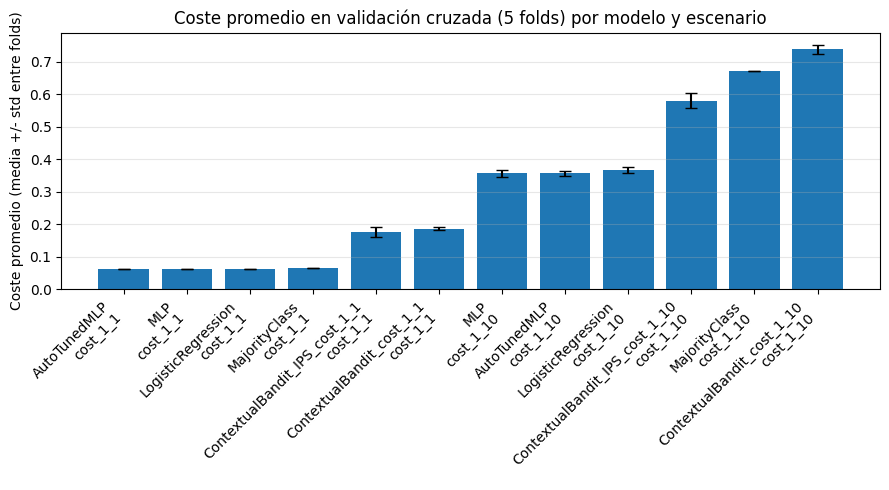

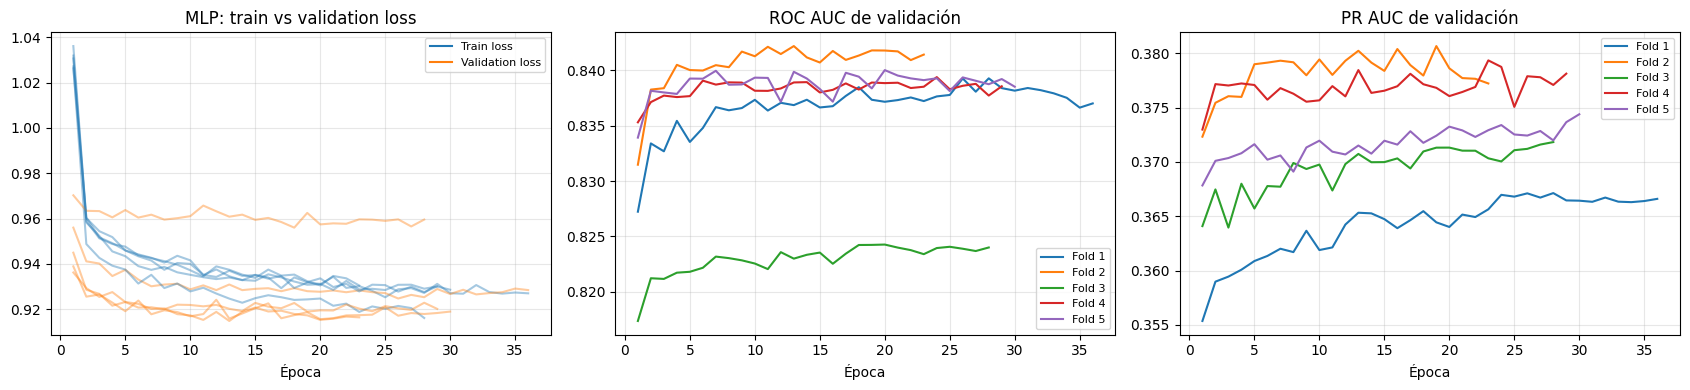

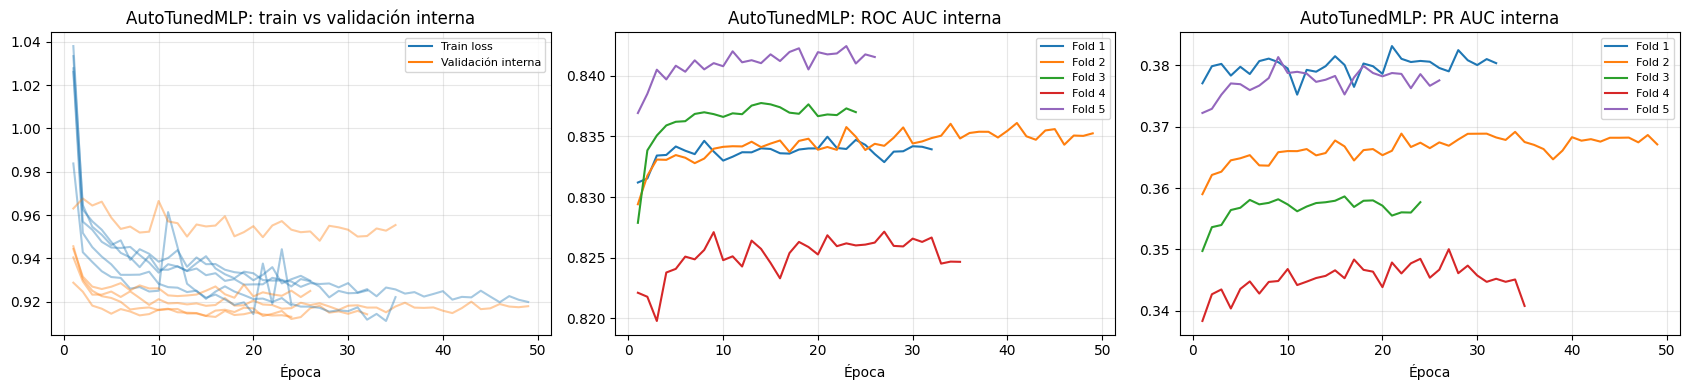

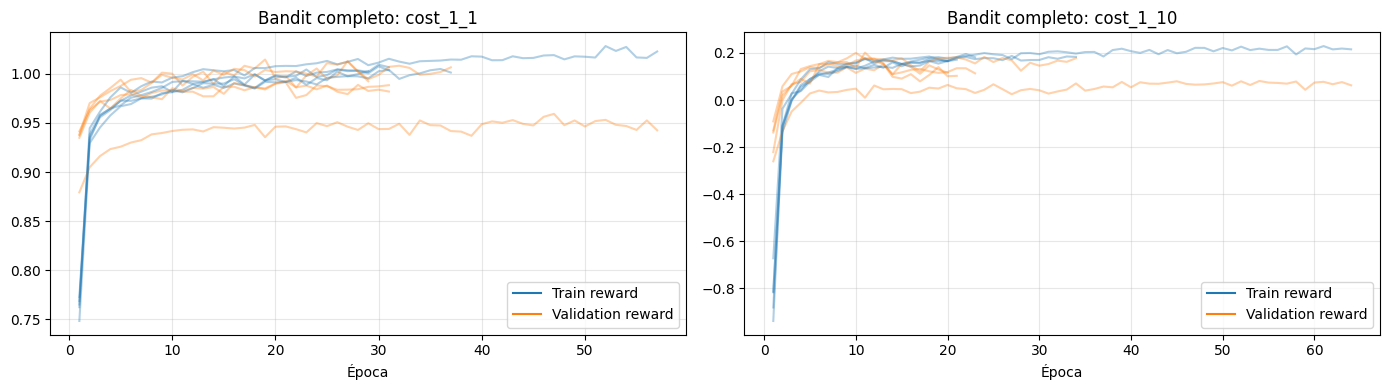

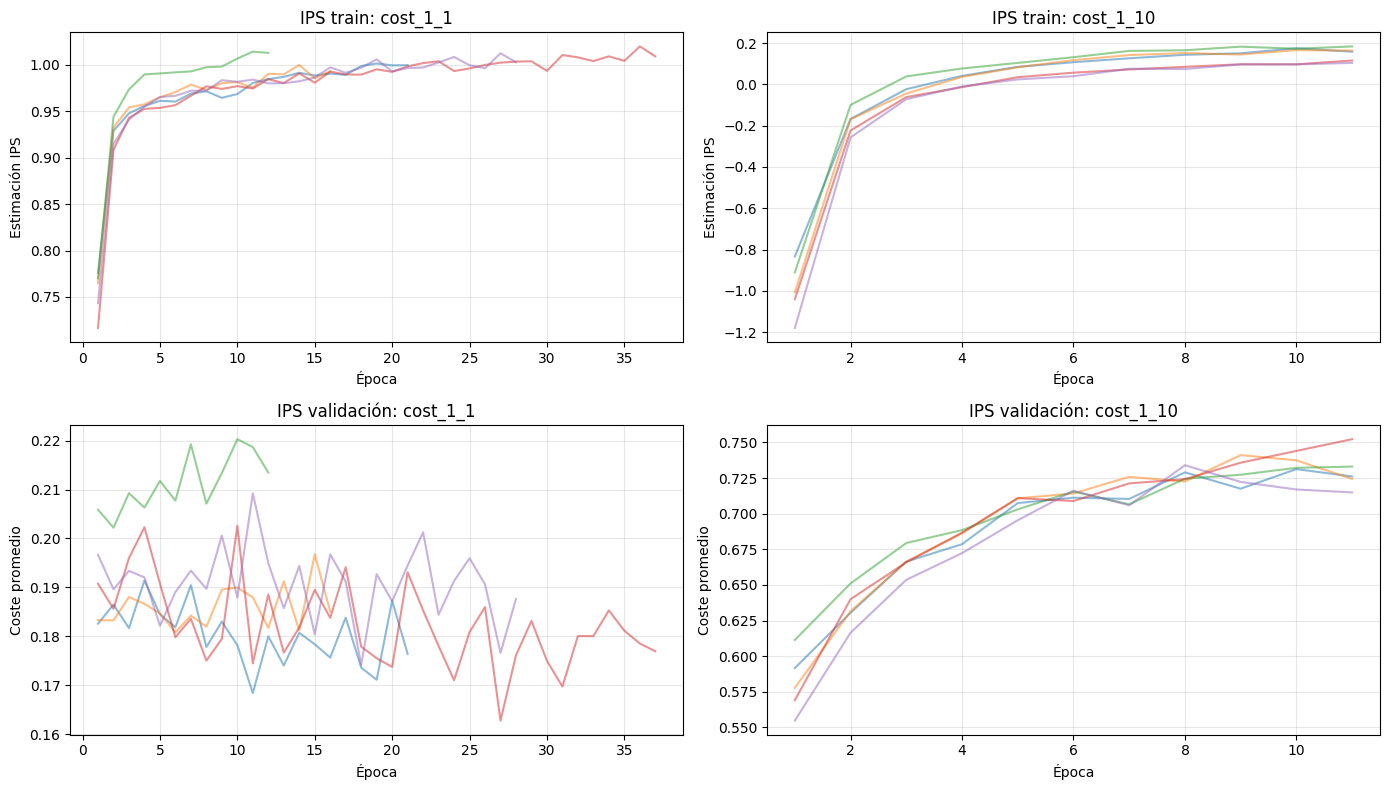

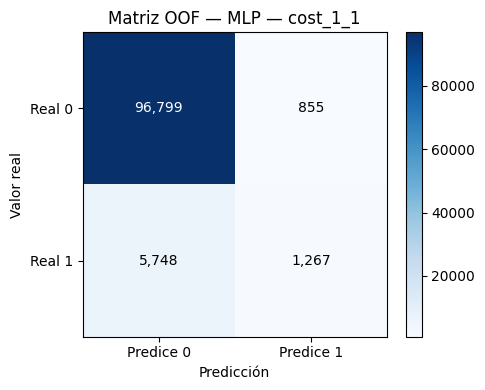


Classification report OOF — cost_1_1
              precision    recall  f1-score   support

           0     0.9439    0.9912    0.9670     97654
           1     0.5971    0.1806    0.2773      7015

    accuracy                         0.9369    104669
   macro avg     0.7705    0.5859    0.6222    104669
weighted avg     0.9207    0.9369    0.9208    104669



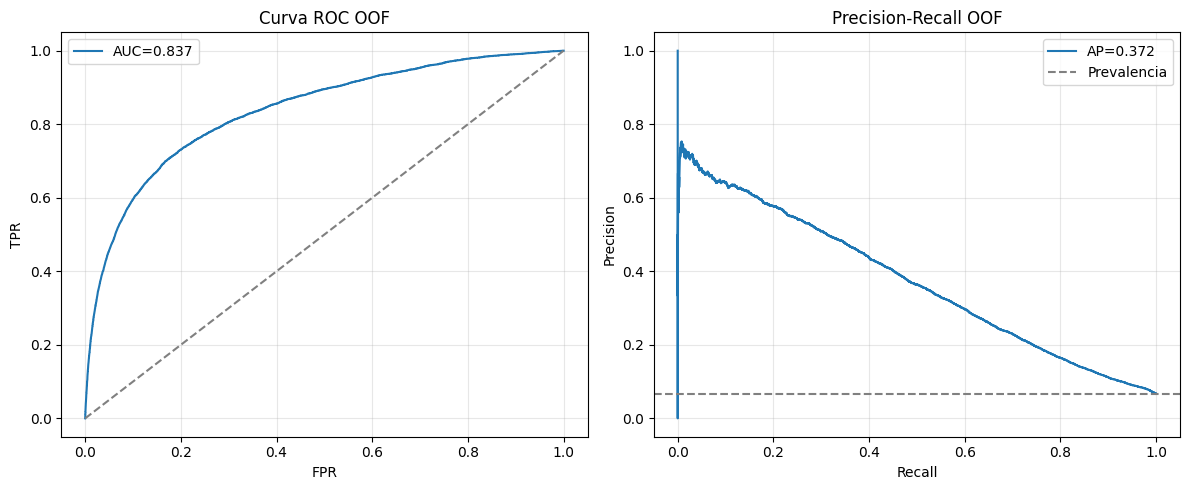

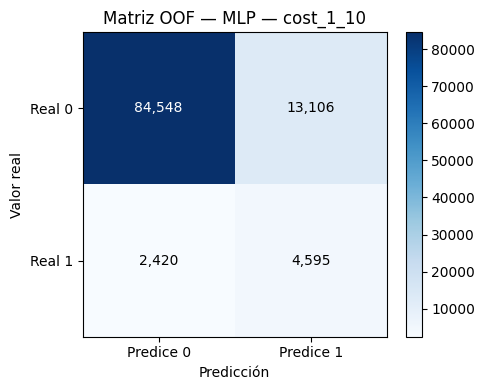


Classification report OOF — cost_1_10
              precision    recall  f1-score   support

           0     0.9722    0.8658    0.9159     97654
           1     0.2596    0.6550    0.3718      7015

    accuracy                         0.8517    104669
   macro avg     0.6159    0.7604    0.6439    104669
weighted avg     0.9244    0.8517    0.8794    104669



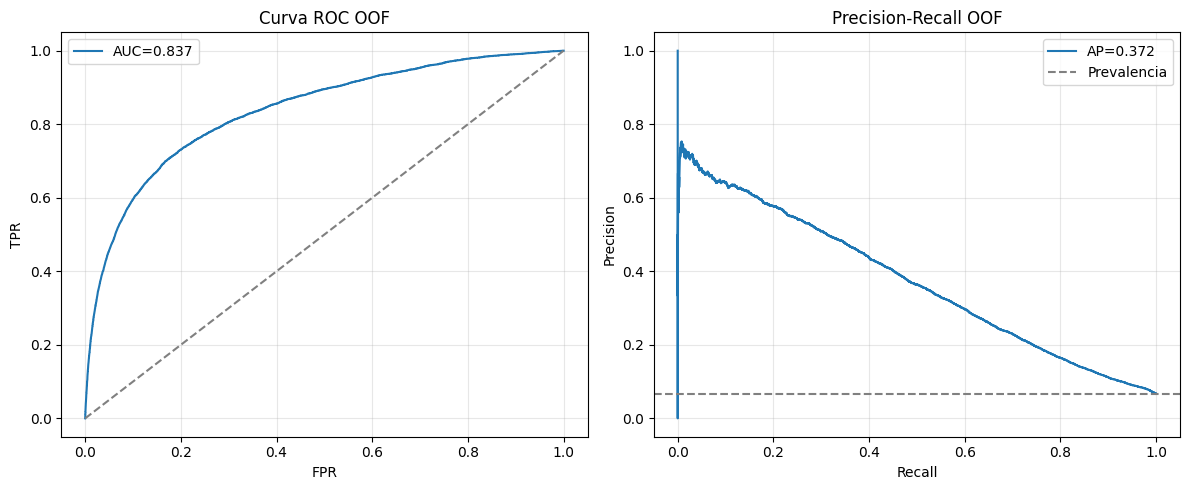

In [25]:
# Coste medio +/- desviación típica por modelo y escenario (barras de error).
plt.figure(figsize=(9, 5))
labels = []
means = []
stds = []
for _, row in cv_summary.iterrows():
    labels.append(f"{row['model']}\n{row['scenario']}")
    means.append(row["avg_cost_mean"])
    stds.append(row["avg_cost_std"])

plt.bar(labels, means, yerr=stds, capsize=4)
plt.title("Coste promedio en validación cruzada (5 folds) por modelo y escenario")
plt.ylabel("Coste promedio (media +/- std entre folds)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cv_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ================================================================
# GRÁFICAS DE DIAGNÓSTICO DE LA VALIDACIÓN CRUZADA
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for fold_idx, hist in fold_mlp_histories.items():
    axes[0].plot(hist["epoch"], hist["train_loss"], color="tab:blue", alpha=0.4)
    axes[0].plot(hist["epoch"], hist["val_loss"], color="tab:orange", alpha=0.4)
    axes[1].plot(hist["epoch"], hist["val_roc_auc"], label=f"Fold {fold_idx}")
    axes[2].plot(hist["epoch"], hist["val_pr_auc"], label=f"Fold {fold_idx}")
axes[0].plot([], [], color="tab:blue", label="Train loss")
axes[0].plot([], [], color="tab:orange", label="Validation loss")
axes[0].set_title("MLP: train vs validation loss")
axes[1].set_title("ROC AUC de validación")
axes[2].set_title("PR AUC de validación")
for ax in axes:
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "mlp_cv_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Curvas de las configuraciones AutoTunedMLP ganadoras en cada fold.
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for fold_idx, hist in fold_tuned_mlp_histories.items():
    axes[0].plot(hist["epoch"], hist["train_loss"], color="tab:blue", alpha=0.4)
    axes[0].plot(hist["epoch"], hist["val_loss"], color="tab:orange", alpha=0.4)
    axes[1].plot(hist["epoch"], hist["val_roc_auc"], label=f"Fold {fold_idx}")
    axes[2].plot(hist["epoch"], hist["val_pr_auc"], label=f"Fold {fold_idx}")
axes[0].plot([], [], color="tab:blue", label="Train loss")
axes[0].plot([], [], color="tab:orange", label="Validación interna")
axes[0].set_title("AutoTunedMLP: train vs validación interna")
axes[1].set_title("AutoTunedMLP: ROC AUC interna")
axes[2].set_title("AutoTunedMLP: PR AUC interna")
for ax in axes:
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "autotuned_mlp_cv_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Bandit con información completa: train frente a validación.
fig, axes = plt.subplots(1, len(scenarios), figsize=(14, 4), squeeze=False)
for ax, scenario_name in zip(axes.ravel(), scenarios):
    for fold_idx in range(1, N_SPLITS + 1):
        hist = fold_bandit_histories[(fold_idx, scenario_name)]
        ax.plot(hist["epoch"], hist["train_expected_reward"], color="tab:blue", alpha=0.35)
        ax.plot(hist["epoch"], hist["val_expected_reward"], color="tab:orange", alpha=0.35)
    ax.plot([], [], color="tab:blue", label="Train reward")
    ax.plot([], [], color="tab:orange", label="Validation reward")
    ax.set_title(f"Bandit completo: {scenario_name}")
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "bandit_cv_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Bandit IPS: estimación de train y coste de validación en paneles separados.
fig, axes = plt.subplots(2, len(scenarios), figsize=(14, 8), squeeze=False)
for j, scenario_name in enumerate(scenarios):
    for fold_idx in range(1, N_SPLITS + 1):
        hist = fold_ips_bandit_histories[(fold_idx, scenario_name)]
        axes[0, j].plot(hist["epoch"], hist["train_ips_estimate"], alpha=0.5)
        axes[1, j].plot(hist["epoch"], hist["val_avg_cost"], alpha=0.5)
    axes[0, j].set_title(f"IPS train: {scenario_name}")
    axes[1, j].set_title(f"IPS validación: {scenario_name}")
    axes[0, j].set_ylabel("Estimación IPS")
    axes[1, j].set_ylabel("Coste promedio")
    for ax in axes[:, j]:
        ax.set_xlabel("Época")
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "ips_bandit_cv_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# MATRICES DE CONFUSIÓN Y CURVAS OOF DE LA MLP
for scenario_name in scenarios:
    result = oof_mlp_df[oof_mlp_df["scenario"] == scenario_name]
    cm = confusion_matrix(result["y_true"], result["y_pred"], labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cm, cmap="Blues")
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f"{cm[row, col]:,}", ha="center", va="center",
                    color="white" if cm[row, col] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], labels=["Predice 0", "Predice 1"])
    ax.set_yticks([0, 1], labels=["Real 0", "Real 1"])
    ax.set(xlabel="Predicción", ylabel="Valor real", title=f"Matriz OOF — MLP — {scenario_name}")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"mlp_oof_confusion_{scenario_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nClassification report OOF — {scenario_name}")
    print(classification_report(result["y_true"], result["y_pred"], digits=4, zero_division=0))
    fpr, tpr, _ = roc_curve(result["y_true"], result["y_proba"])
    precision, recall, _ = precision_recall_curve(result["y_true"], result["y_proba"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(result['y_true'], result['y_proba']):.3f}")
    axes[0].plot([0, 1], [0, 1], "--", color="gray")
    axes[0].set(xlabel="FPR", ylabel="TPR", title="Curva ROC OOF")
    axes[1].plot(recall, precision, label=f"AP={average_precision_score(result['y_true'], result['y_proba']):.3f}")
    axes[1].axhline(result["y_true"].mean(), linestyle="--", color="gray", label="Prevalencia")
    axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall OOF")
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"mlp_oof_roc_pr_{scenario_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 7. Reentrenamiento final con todo `cs_construccion.csv`

Una vez elegidos los thresholds (media de la validación cruzada) y el mejor
modelo por escenario, reentrenamos los modelos sobre todo `cs_construccion.csv`
para aprovechar todos los datos antes de predecir producción.

Mantenemos los thresholds aprendidos en la CV, porque son parte de la política
de decisión. En un proyecto real se conservaría un conjunto de test separado;
aquí el objetivo es generar predicciones para producción con la mejor
información disponible.

Entrenamos muchas más épocas para mejorar convergencia.

Reentrenando MLP final...
Epoch 001 | train_loss=1.0364 | val_loss=0.9384 | val_auc=0.8389 | lr=1.00e-03
Epoch 005 | train_loss=0.9443 | val_loss=0.9179 | val_auc=0.8440 | lr=1.00e-03
Epoch 010 | train_loss=0.9378 | val_loss=0.9106 | val_auc=0.8472 | lr=1.00e-03
Epoch 015 | train_loss=0.9352 | val_loss=0.9140 | val_auc=0.8481 | lr=1.00e-03
Epoch 020 | train_loss=0.9317 | val_loss=0.9106 | val_auc=0.8481 | lr=1.00e-03
Epoch 025 | train_loss=0.9281 | val_loss=0.9123 | val_auc=0.8479 | lr=1.00e-03
Epoch 030 | train_loss=0.9295 | val_loss=0.9130 | val_auc=0.8473 | lr=1.00e-03
Epoch 035 | train_loss=0.9278 | val_loss=0.9125 | val_auc=0.8487 | lr=1.00e-03
Epoch 040 | train_loss=0.9246 | val_loss=0.9069 | val_auc=0.8486 | lr=1.00e-03
Epoch 045 | train_loss=0.9240 | val_loss=0.9081 | val_auc=0.8493 | lr=1.00e-03
Epoch 050 | train_loss=0.9236 | val_loss=0.9119 | val_auc=0.8496 | lr=1.00e-03
Epoch 055 | train_loss=0.9229 | val_loss=0.9075 | val_auc=0.8491 | lr=1.00e-03
Epoch 060 | train_loss=0.9

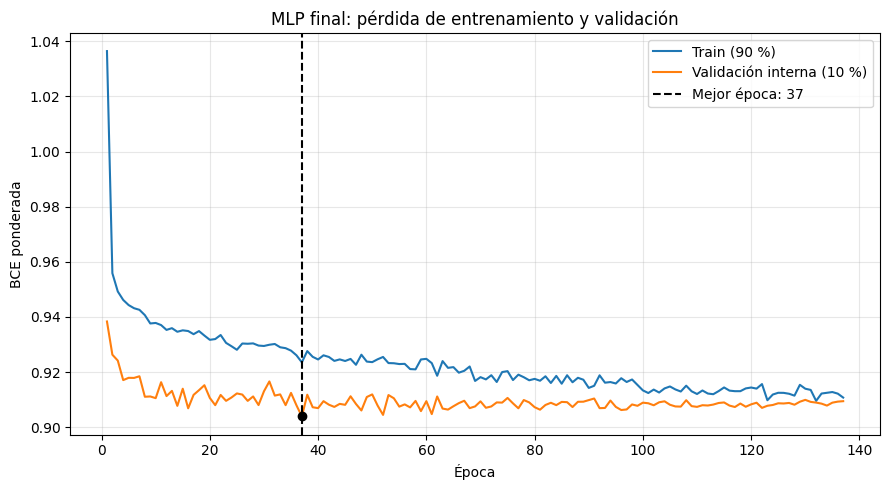

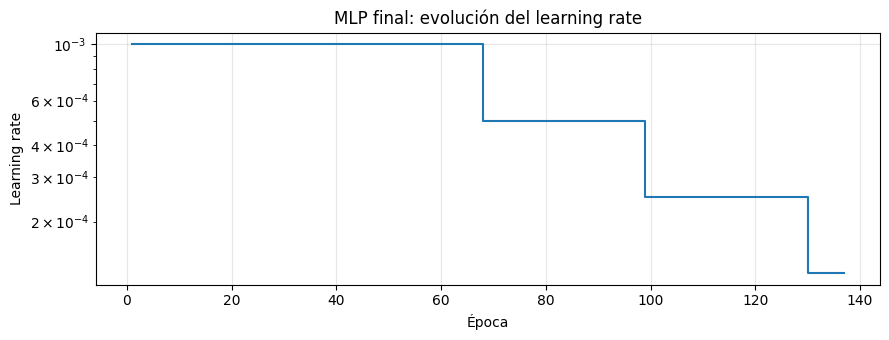


Buscando la mejor configuración del AutoTunedMLP final...

--- AutoTunedMLP trial 1/5: {'hidden_dims': (128, 64, 32), 'dropout': 0.25, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 1024, 'use_pos_weight': True} ---
Epoch 001 | train_loss=1.0159 | val_loss=0.9380 | val_auc=0.8412 | lr=1.00e-03
Epoch 005 | train_loss=0.9454 | val_loss=0.9149 | val_auc=0.8475 | lr=1.00e-03
Epoch 010 | train_loss=0.9370 | val_loss=0.9094 | val_auc=0.8489 | lr=1.00e-03
Epoch 015 | train_loss=0.9332 | val_loss=0.9072 | val_auc=0.8495 | lr=1.00e-03
Epoch 020 | train_loss=0.9315 | val_loss=0.9047 | val_auc=0.8501 | lr=1.00e-03
Epoch 025 | train_loss=0.9311 | val_loss=0.9139 | val_auc=0.8490 | lr=1.00e-03
Epoch 030 | train_loss=0.9282 | val_loss=0.9117 | val_auc=0.8487 | lr=1.00e-03
Epoch 035 | train_loss=0.9290 | val_loss=0.9113 | val_auc=0.8485 | lr=1.00e-03
Epoch 040 | train_loss=0.9276 | val_loss=0.9109 | val_auc=0.8485 | lr=1.00e-03
Epoch 045 | train_loss=0.9224 | val_loss=0.9093 | val_auc=0.8489 | l

,trial,pr_auc,roc_auc,hidden_dims,dropout,lr,weight_decay,batch_size,use_pos_weight
0,1,0.3732,0.8497,"(128, 64, 32)",0.2500,0.0010,0.0001,1024,True
3,4,0.3717,0.8496,"(128, 64, 16)",0.1500,0.0005,0.0005,512,True
4,5,0.3716,0.8502,"(128, 64, 32)",0.2000,0.0010,0.0001,1024,False
1,2,0.3713,0.8506,"(256, 128, 64)",0.3000,0.0005,0.0001,1024,True
2,3,0.3689,0.8507,"(256, 128, 32)",0.2000,0.0010,0.0001,512,True


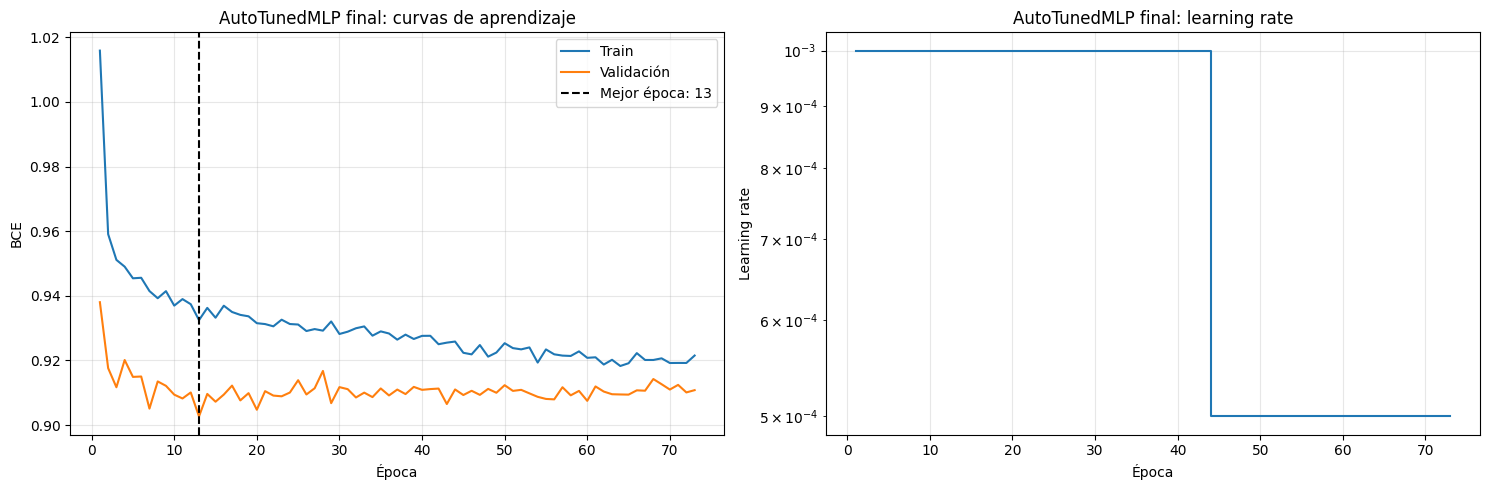


Reentrenando bandit (info. completa) final para cost_1_1
Epoch 001 | train_reward=0.8183 | val_reward=0.9718 | val_cost=0.1843
Epoch 005 | train_reward=0.9735 | val_reward=1.0113 | val_cost=0.1826
Epoch 010 | train_reward=0.9836 | val_reward=1.0133 | val_cost=0.1836
Epoch 015 | train_reward=0.9910 | val_reward=1.0114 | val_cost=0.1820
Epoch 020 | train_reward=0.9925 | val_reward=1.0017 | val_cost=0.1874
Epoch 025 | train_reward=0.9963 | val_reward=1.0040 | val_cost=0.1798
Epoch 030 | train_reward=0.9952 | val_reward=1.0246 | val_cost=0.1951
Epoch 035 | train_reward=0.9961 | val_reward=1.0146 | val_cost=0.1876
Epoch 040 | train_reward=1.0028 | val_reward=1.0171 | val_cost=0.1887
Epoch 045 | train_reward=1.0048 | val_reward=1.0112 | val_cost=0.1913
Epoch 050 | train_reward=1.0013 | val_reward=1.0074 | val_cost=0.1851
Epoch 055 | train_reward=1.0063 | val_reward=1.0255 | val_cost=0.1850
Epoch 060 | train_reward=1.0035 | val_reward=1.0414 | val_cost=0.1841
Epoch 065 | train_reward=1.0073 

In [26]:
# Escalamos todo el dataset de construcción con un scaler final.
final_scaler = StandardScaler()
X_all_scaled = final_scaler.fit_transform(X)
y_all = y.copy()

joblib.dump(final_scaler, OBJECTS_DIR / "final_model_scaler.joblib")

# Para tener early stopping, dentro del reentrenamiento hacemos un pequeño split interno.
X_tr_full, X_es, y_tr_full, y_es = train_test_split(
    X_all_scaled,
    y_all,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

final_models = {}
final_bandit_histories = {}
final_ips_bandit_histories = {}
model_metadata = {
    "target": TARGET,
    "features": FEATURES,
    "scenarios": scenarios,
    "cv_results": cv_results_df.to_dict(orient="records"),
    "cv_summary": cv_summary.to_dict(orient="records"),
    "best_by_scenario_cv": best_by_scenario_cv.to_dict(orient="records"),
}

# Regresión logística final ajustada con todo construcción.
final_logreg = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE,
)
final_logreg.fit(X_all_scaled, y_all)
joblib.dump(final_logreg, MODELS_DIR / "final_logistic_regression.joblib")

# Reentrenamos MLP final.
print("Reentrenando MLP final...")
final_mlp, final_mlp_history = train_mlp(
    X_tr_full,
    y_tr_full,
    X_es,
    y_es,
    input_dim=X_all_scaled.shape[1],
    lr=1e-3,
    batch_size=1024,
    max_epochs=300,
    patience=100,
    lr_scheduler_patience=30,
    lr_scheduler_factor=0.5,
    min_lr=1e-5,
)
final_models["MLP"] = final_mlp

# ================================================================
# CURVA DE APRENDIZAJE DE LA MLP FINAL
# ================================================================
plt.figure(figsize=(9, 5))
plt.plot(final_mlp_history["epoch"], final_mlp_history["train_loss"], label="Train (90 %)")
plt.plot(final_mlp_history["epoch"], final_mlp_history["val_loss"], label="Validación interna (10 %)")
best_epoch = int(final_mlp_history.loc[final_mlp_history["val_loss"].idxmin(), "epoch"])
best_val_loss = float(final_mlp_history["val_loss"].min())
plt.axvline(best_epoch, color="black", linestyle="--", label=f"Mejor época: {best_epoch}")
plt.scatter([best_epoch], [best_val_loss], color="black", zorder=3)
plt.title("MLP final: pérdida de entrenamiento y validación")
plt.xlabel("Época")
plt.ylabel("BCE ponderada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "final_mlp_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Evolución del learning rate de la MLP final.
plt.figure(figsize=(9, 3.5))
plt.step(final_mlp_history["epoch"], final_mlp_history["learning_rate"], where="post")
plt.yscale("log")
plt.title("MLP final: evolución del learning rate")
plt.xlabel("Época")
plt.ylabel("Learning rate")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "final_mlp_learning_rate.png", dpi=150, bbox_inches="tight")
plt.show()

# Búsqueda automática y entrenamiento del AutoTunedMLP final.
print("\nBuscando la mejor configuración del AutoTunedMLP final...")
final_tuned_mlp, final_tuned_history, final_tuned_config, final_tuned_trials = search_mlp_configs(
    X_tr_full, y_tr_full, X_es, y_es,
    input_dim=X_all_scaled.shape[1],
    max_epochs=150, patience=60, scheduler_patience=30,
)
final_models["AutoTunedMLP"] = final_tuned_mlp

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(final_tuned_history["epoch"], final_tuned_history["train_loss"], label="Train")
axes[0].plot(final_tuned_history["epoch"], final_tuned_history["val_loss"], label="Validación")
tuned_best_epoch = int(final_tuned_history.loc[final_tuned_history["val_loss"].idxmin(), "epoch"])
axes[0].axvline(tuned_best_epoch, color="black", linestyle="--", label=f"Mejor época: {tuned_best_epoch}")
axes[0].set(title="AutoTunedMLP final: curvas de aprendizaje", xlabel="Época", ylabel="BCE")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].step(final_tuned_history["epoch"], final_tuned_history["learning_rate"], where="post")
axes[1].set_yscale("log")
axes[1].set(title="AutoTunedMLP final: learning rate", xlabel="Época", ylabel="Learning rate")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "final_autotuned_mlp_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Reentrenamos bandits finales (información completa) por escenario.
for scenario_name, params in scenarios.items():
    print("\nReentrenando bandit (info. completa) final para", scenario_name)
    final_bandit, final_bandit_history = train_contextual_bandit(
        X_tr_full,
        y_tr_full,
        X_es,
        y_es,
        fp_cost=params["fp_cost"],
        fn_cost=params["fn_cost"],
        input_dim=X_all_scaled.shape[1],
        lr=1e-3,
        batch_size=1024,
        max_epochs=300,
        patience=100,
        use_pos_weight=True,
    )
    final_models[f"ContextualBandit_{scenario_name}"] = final_bandit
    final_bandit_histories[scenario_name] = final_bandit_history

# Reentrenamos el bandit IPS (feedback parcial) final por escenario.
# La política de logging se simula sobre el split de entrenamiento del
# reentrenamiento final (X_tr_full), una sola vez, y se reutiliza para
# los dos escenarios.
final_logged_action, final_propensity, _final_logging_model = logging_policy_and_propensities(
    X_tr_full, y_tr_full, epsilon=LOGGING_EPSILON, random_state=RANDOM_STATE,
)

for scenario_name, params in scenarios.items():
    print("\nReentrenando bandit IPS (feedback parcial) final para", scenario_name)
    n_pos = float((y_tr_full == 1).sum())
    n_neg = float((y_tr_full == 0).sum())
    pos_weight_full = n_neg / max(n_pos, 1.0)

    final_reward_tr = logged_reward(
        y_tr_full.values, final_logged_action,
        fp_cost=params["fp_cost"], fn_cost=params["fn_cost"], pos_weight=pos_weight_full,
    )

    final_ips_bandit, final_ips_history = train_ips_bandit(
        X_tr_full, y_tr_full, final_logged_action, final_propensity, final_reward_tr,
        X_es, y_es,
        fp_cost=params["fp_cost"], fn_cost=params["fn_cost"],
        input_dim=X_all_scaled.shape[1],
        lr=1e-3, batch_size=1024, max_epochs=300, patience=100,
    )
    final_models[f"ContextualBandit_IPS_{scenario_name}"] = final_ips_bandit
    final_ips_bandit_histories[scenario_name] = final_ips_history


In [27]:
# Guardamos modelos PyTorch y metadatos.
torch.save({
    "model_type": "MLP",
    "input_dim": X_all_scaled.shape[1],
    "hidden_dims": (128, 64, 32),
    "dropout": 0.25,
    "state_dict": final_models["MLP"].state_dict(),
}, MODELS_DIR / "final_mlp.pt")

torch.save({
    "model_type": "MLP",
    "input_dim": X_all_scaled.shape[1],
    "hidden_dims": tuple(final_tuned_config["hidden_dims"]),
    "dropout": final_tuned_config["dropout"],
    "state_dict": final_models["AutoTunedMLP"].state_dict(),
}, MODELS_DIR / "final_autotuned_mlp.pt")

for scenario_name in scenarios.keys():
    model_name = f"ContextualBandit_{scenario_name}"
    torch.save({
        "model_type": "ContextualBanditPolicy",
        "input_dim": X_all_scaled.shape[1],
        "hidden_dims": (128, 64),
        "dropout": 0.20,
        "state_dict": final_models[model_name].state_dict(),
    }, MODELS_DIR / f"final_bandit_{scenario_name}.pt")

    ips_model_name = f"ContextualBandit_IPS_{scenario_name}"
    torch.save({
        "model_type": "ContextualBanditPolicy_IPS",
        "input_dim": X_all_scaled.shape[1],
        "hidden_dims": (128, 64),
        "dropout": 0.20,
        "state_dict": final_models[ips_model_name].state_dict(),
    }, MODELS_DIR / f"final_bandit_ips_{scenario_name}.pt")

# Threshold final de la MLP por escenario: media de los 5 folds de la CV.
model_metadata["mlp_thresholds"] = mlp_thresholds_cv
model_metadata["logreg_thresholds"] = logreg_thresholds_cv
model_metadata["autotuned_mlp_thresholds"] = tuned_mlp_thresholds_cv
model_metadata["autotuned_mlp_config"] = final_tuned_config

# Indicamos qué modelo se usará por defecto en cada escenario, según la CV.
# Puede ser MLP, bandit de información completa, o bandit IPS (feedback parcial).
selected_models = {}
for _, row in best_by_scenario_cv.iterrows():
    scenario = row["scenario"]
    model = row["model"]
    if model == "MLP":
        selected_models[scenario] = {
            "model_family": "MLP",
            "model_file": "final_mlp.pt",
            "threshold": mlp_thresholds_cv[scenario],
        }
    elif model == "AutoTunedMLP":
        selected_models[scenario] = {
            "model_family": "MLP",
            "model_file": "final_autotuned_mlp.pt",
            "threshold": tuned_mlp_thresholds_cv[scenario],
            "selection_name": "AutoTunedMLP",
        }
    elif model == "LogisticRegression":
        selected_models[scenario] = {
            "model_family": "LogisticRegression",
            "model_file": "final_logistic_regression.joblib",
            "threshold": logreg_thresholds_cv[scenario],
        }
    elif model == "MajorityClass":
        selected_models[scenario] = {
            "model_family": "MajorityClass",
            "model_file": None,
            "threshold": 0.5,
            "majority_class": int(y_all.mode().iloc[0]),
        }
    elif model.startswith("ContextualBandit_IPS"):
        selected_models[scenario] = {
            "model_family": "ContextualBanditPolicy_IPS",
            "model_file": f"final_bandit_ips_{scenario}.pt",
            "threshold": 0.5,
        }
    else:
        selected_models[scenario] = {
            "model_family": "ContextualBanditPolicy",
            "model_file": f"final_bandit_{scenario}.pt",
            "threshold": 0.5,
        }

model_metadata["selected_models"] = selected_models

joblib.dump(model_metadata, MODELS_DIR / "model_metadata.joblib")
cv_results_df.to_csv(OUTPUT_DIR / "cv_results.csv", index=False)
cv_summary.to_csv(OUTPUT_DIR / "cv_summary.csv", index=False)
cv_thresholds_df.to_csv(OUTPUT_DIR / "cv_thresholds.csv", index=False)
oof_mlp_df.to_csv(OUTPUT_DIR / "mlp_oof_predictions.csv", index=False)
final_mlp_history.to_csv(OUTPUT_DIR / "final_mlp_history.csv", index=False)
final_tuned_history.to_csv(OUTPUT_DIR / "final_autotuned_mlp_history.csv", index=False)
final_tuned_trials.to_csv(OUTPUT_DIR / "final_autotuned_mlp_trials.csv", index=False)
pd.DataFrame([
    {"fold": fold, **config} for fold, config in fold_tuned_mlp_configs.items()
]).to_csv(OUTPUT_DIR / "autotuned_mlp_fold_configs.csv", index=False)
pd.concat([
    trials.assign(fold=fold) for fold, trials in fold_tuned_mlp_trials.items()
], ignore_index=True).to_csv(OUTPUT_DIR / "autotuned_mlp_cv_trials.csv", index=False)

# Históricos de los bandits finales (información completa e IPS).
for scenario_name, hist in final_bandit_histories.items():
    hist.to_csv(OUTPUT_DIR / f"final_bandit_history_{scenario_name}.csv", index=False)
for scenario_name, hist in final_ips_bandit_histories.items():
    hist.to_csv(OUTPUT_DIR / f"final_bandit_ips_history_{scenario_name}.csv", index=False)

print("Modelos guardados en:", MODELS_DIR.resolve())
print("Modelo seleccionado por escenario:")
print(json.dumps(selected_models, indent=2))


Modelos guardados en: C:\Users\Miriamdbg\Desktop\MIAX\Tareas\Tarea_16_XAI_I\outputs\models
Modelo seleccionado por escenario:
{
  "cost_1_1": {
    "model_family": "MLP",
    "model_file": "final_autotuned_mlp.pt",
    "threshold": 0.9216969696969697,
    "selection_name": "AutoTunedMLP"
  },
  "cost_1_10": {
    "model_family": "MLP",
    "model_file": "final_mlp.pt",
    "threshold": 0.597010101010101
  }
}


## 8. Conclusiones del modelado

Aspectos clave para comentar:

1. Se ha entrenado una red neuronal supervisada (MLP) que estima la probabilidad de mora
2. Se han entrenado **dos versiones** de bandit contextual — la opción **b) Multiarmed Bandit**:
   - **Información completa**: ve la recompensa de las dos acciones a la vez para cada cliente. Es una simplificación (más cercana a un clasificador sensible al coste vía policy gradient), útil como referencia, pero no un bandit "puro".
   - **IPS (feedback parcial)**: simula una política de logging (regresión logística epsilon-greedy) y aprende solo de la recompensa de la acción observada, corrigiendo el sesgo con Inverse Propensity Scoring. Este sí respeta el planteamiento real de un bandit contextual.
3. **La MLP gana claramente a los dos bandits en los dos escenarios de coste**, con baja variabilidad entre los 5 folds de la CV. Por eso la MLP es el modelo elegido para producción en los dos escenarios.
4. **La brecha entre modelos se amplía en el escenario más exigente** (FP=1, FN=10): el bandit de información completa pasa de estar cerca del IPS en el escenario 1 a quedar muy por detrás en el escenario 2 (0.734 vs 0.593). Indica que la MLP generaliza mejor cuando el coste de los falsos negativos se dispara.
5. **El bandit IPS (el metodológicamente correcto) supera de forma consistente al de información completa** en los dos escenarios — un resultado que vale la pena destacar: la versión más "honesta" (feedback parcial) no solo es más rigurosa, también funcionó mejor en la práctica.
6. Al bandit de información completa se le añadió un ajuste tipo `pos_weight` (igual que en la MLP) para compensar el desbalanceo de clases: sin él, su ROC AUC en el escenario FP=FN=1 era 0.499 (equivalente al azar); con el ajuste, subió a 0.817.
7. El threshold de decisión de la MLP no se fija en 0.5: se optimiza según coste mediante validación cruzada de 5 folds. Los valores finales son **0.923** (escenario FP=FN=1, umbral alto porque solo conviene denegar cuando hay mucha certeza) y **0.555** (escenario FP=1,FN=10, umbral más bajo porque conviene denegar con menos certeza, ya que el error de conceder sale mucho más caro).
8. El modelo final por escenario queda guardado para producción y para el análisis XAI.

El siguiente notebook audita el modelo elegido (MLP) mediante SHAP, modelo subrogado y contrafactuales.
